In [60]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
from sklearn.externals.six import StringIO
from IPython.display import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pydotplus

df_diabetes = pd.read_csv("data/diabetes.csv")
label = 'Outcome'
df_diabetes

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [15]:
x = df_diabetes.drop(columns=[label])
y = df_diabetes[label]
feature_cols = x.columns
diabetes_class_names = [str(v) for v in df_diabetes[label].unique()]
clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(x, y)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=3, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

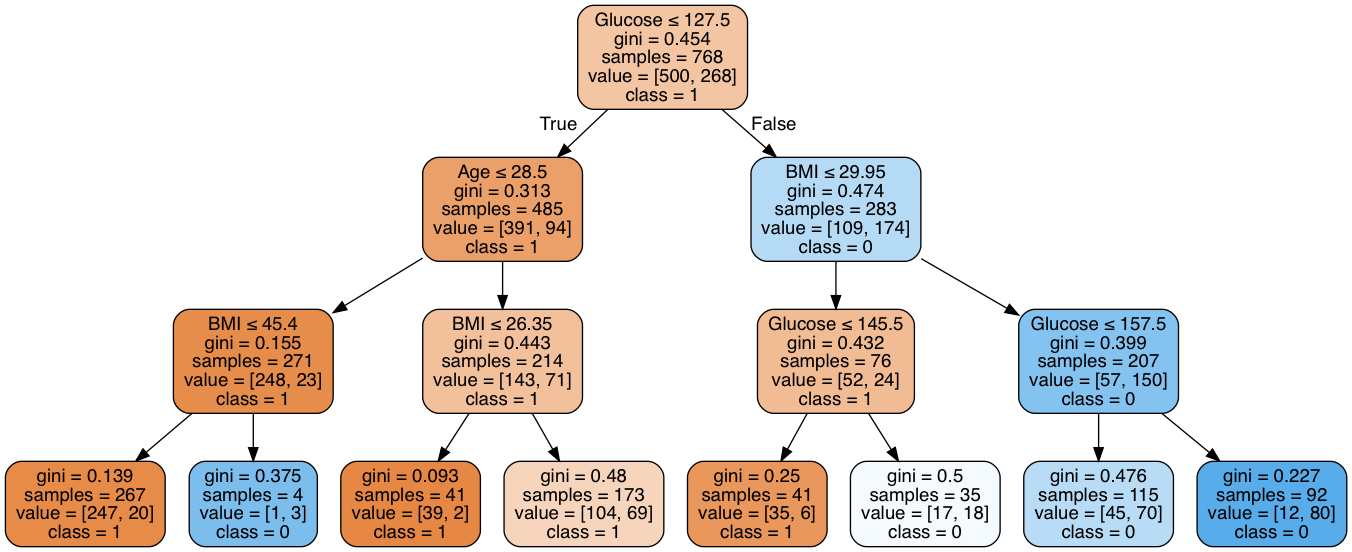

In [17]:
def plot_decision_tree(model, feature_cols, class_names):
    dot_data = StringIO()
    export_graphviz(model, out_file=dot_data, filled=True, rounded=True,
                    special_characters=True, feature_names=feature_cols, class_names=class_names)
    graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
    graph.write_png('diabetes.png')
    return Image(graph.create_png())
    
plot_decision_tree(clf, feature_cols, diabetes_class_names)

In [57]:
df_insurance = pd.read_csv("data/MotorInsuranceFraudClaimABTFull.csv")
df_insurance.isna().sum()

ID                           0
Insurance Type               0
Income of Policy Holder      0
Marital Status             330
Num Claimants                0
Injury Type                  0
Overnight Hospital Stay      0
Claim Amount                 0
Total Claimed                0
Num Claims                   0
Num Soft Tissue             10
% Soft Tissue                0
Claim Amount Received        0
Fraud Flag                   0
dtype: int64

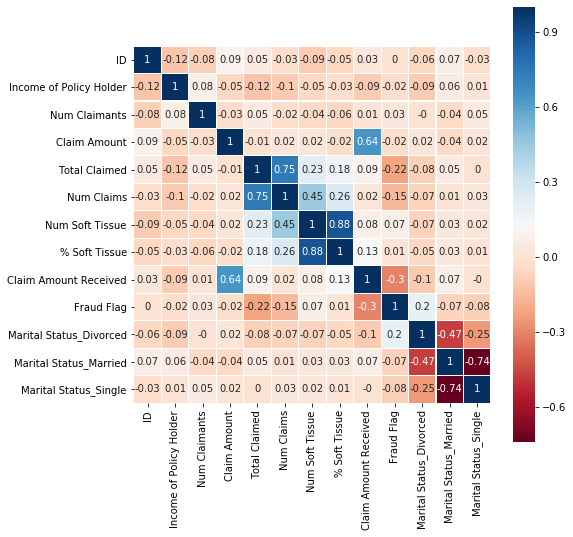

In [58]:
ms_nn = df_insurance.dropna(subset=['Marital Status'])
ms_nn = pd.get_dummies(ms_nn, columns=['Marital Status'])

#ms_nn['Marital Status'] = ms_nn['Marital Status'].map({"Single": 0, "Married": 1, "Divorced":2})
import matplotlib.pyplot as plt
import seaborn as sns 

colormap = plt.cm.RdBu
f, axs = plt.subplots(1, 1, figsize=(8, 8))
#ax = plt.subplot(3, 3, idx + 1)
sns.heatmap(ms_nn.corr(method='pearson', min_periods=1).round(decimals=2), linewidths=0.1, vmax=1.0, square=True,
            cmap=colormap, linecolor='white', annot=True)
#plt.xticks(rotation=30, fontsize=7)
plt.show()

In [54]:
label_insurance = "Fraud Flag"
df_insurance.drop(columns=['Insurance Type ', 'Marital Status'], inplace=True)
df_insurance.dropna(inplace=True)
df_insurance['Overnight Hospital Stay'] = df_insurance['Overnight Hospital Stay'].map({"No": 0, "Yes":1})
x_insurance = df_insurance.drop(columns=[label_insurance])
y_insurance = df_insurance[label_insurance]
feature_cols_insurance = x_insurance.columns
insurance_class_names = [str(v) for v in df_insurance[label_insurance].unique()]
ctg_cols = ['Injury Type']
x_insurance_dummy = pd.get_dummies(x_insurance, columns=ctg_cols)
x_insurance_dummy

,ID,Income of Policy Holder,Num Claimants,Overnight Hospital Stay,Claim Amount,Total Claimed,Num Claims,Num Soft Tissue,% Soft Tissue,Claim Amount Received,Injury Type_Back,Injury Type_Broken Limb,Injury Type_Serious,Injury Type_Soft Tissue
0,1,0,2,0,1625,3250,2,2.0,1.0,0,0,0,0,1
1,2,0,2,1,15028,60112,1,0.0,0.0,15028,1,0,0,0
2,3,54613,1,0,-99999,0,0,0.0,0.0,572,0,1,0,0
3,4,0,3,1,270200,0,0,0.0,0.0,270200,0,0,1,0
4,5,0,4,0,8869,0,0,0.0,0.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
494,495,0,2,0,3813,9882,3,0.0,0.0,0,1,0,0,0
495,496,0,1,0,2118,0,0,0.0,0.0,0,0,0,0,1
497,498,0,1,1,32469,0,0,0.0,0.0,16763,0,1,0,0
498,499,46683,1,0,179448,0,0,0.0,0.0,179448,0,1,0,0


Accuracy: 0.9931972789115646


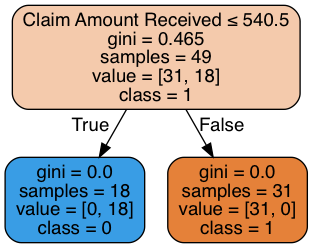

In [83]:
x_train, x_test, y_train, y_test = train_test_split(x_insurance_dummy, y_insurance, test_size=0.9, random_state=1)

clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
plot_decision_tree(clf, x_insurance_dummy.columns, insurance_class_names)

Accuracy: 0.9931972789115646


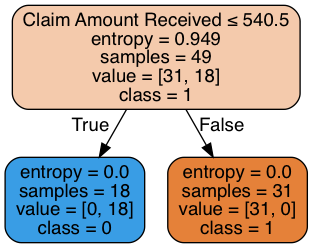

In [79]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf_entropy.fit(x_train, y_train)
y_pred_2 = clf_entropy.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_2))
plot_decision_tree(clf_entropy, x_insurance_dummy.columns, insurance_class_names)

Accuracy: 1.0


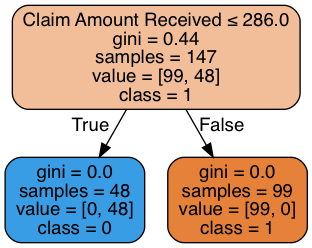

In [80]:
x_train, x_test, y_train, y_test = train_test_split(x_insurance_dummy, y_insurance, test_size=0.7, random_state=1)
clf = DecisionTreeClassifier(criterion='gini', max_depth=3)
clf.fit(x_train, y_train)
y_pred = clf.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
plot_decision_tree(clf, x_insurance_dummy.columns, insurance_class_names)

Accuracy: 1.0


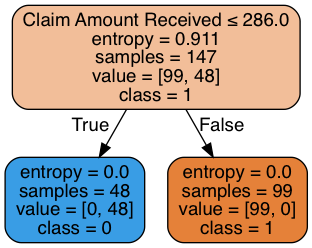

In [81]:
clf_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=3)
clf_entropy.fit(x_train, y_train)
y_pred_2 = clf_entropy.predict(x_test)

print("Accuracy:", accuracy_score(y_test, y_pred_2))
plot_decision_tree(clf_entropy, x_insurance_dummy.columns, insurance_class_names)